In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
my_dataset_url = "/content/Data4Change/Market.csv"

In [27]:
df = pd.read_csv("/content/Data4Change/Market.csv")

In [28]:
print(df.head())

  Index        Date        Open        High         Low       Close  \
0   NYA  12/31/1965  528.690002  528.690002  528.690002  528.690002   
1   NYA    1/3/1966  527.210022  527.210022  527.210022  527.210022   
2   NYA    1/4/1966  527.840027  527.840027  527.840027  527.840027   
3   NYA    1/5/1966  531.119995  531.119995  531.119995  531.119995   
4   NYA    1/6/1966  532.070007  532.070007  532.070007  532.070007   

    Adj Close  Volume  
0  528.690002     0.0  
1  527.210022     0.0  
2  527.840027     0.0  
3  531.119995     0.0  
4  532.070007     0.0  


In [29]:
# Data Cleaning
df.isnull().sum()
df_clean = df.dropna()
pd.to_datetime(df['Date'])
df.drop_duplicates()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0
...,...,...,...,...,...,...,...,...
112452,N100,5/27/2021,1241.119995,1251.910034,1241.119995,1247.069946,1247.069946,379696400.0
112453,N100,5/28/2021,1249.469971,1259.209961,1249.030029,1256.599976,1256.599976,160773400.0
112454,N100,5/31/2021,1256.079956,1258.880005,1248.140015,1248.930054,1248.930054,91173700.0
112455,N100,6/1/2021,1254.609985,1265.660034,1254.609985,1258.579956,1258.579956,155179900.0


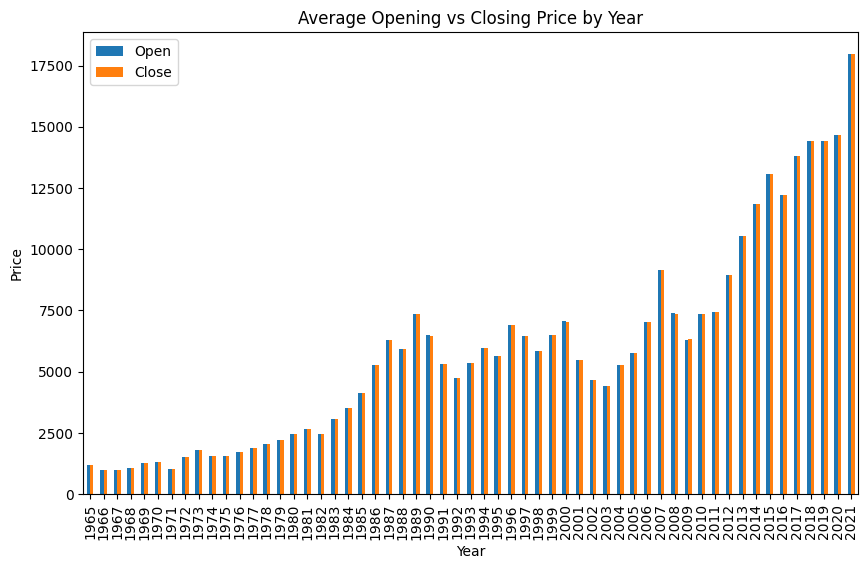

In [30]:
# First Question: How does the average opening price compare to closing price each month of the year?
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
yearly_avg = df.groupby("Year")[["Open", "Close"]].mean()
yearly_avg.plot(kind="bar", figsize=(10,6))
plt.title("Average Opening vs Closing Price by Year")
plt.ylabel("Price")
plt.xlabel("Year")
plt.show()

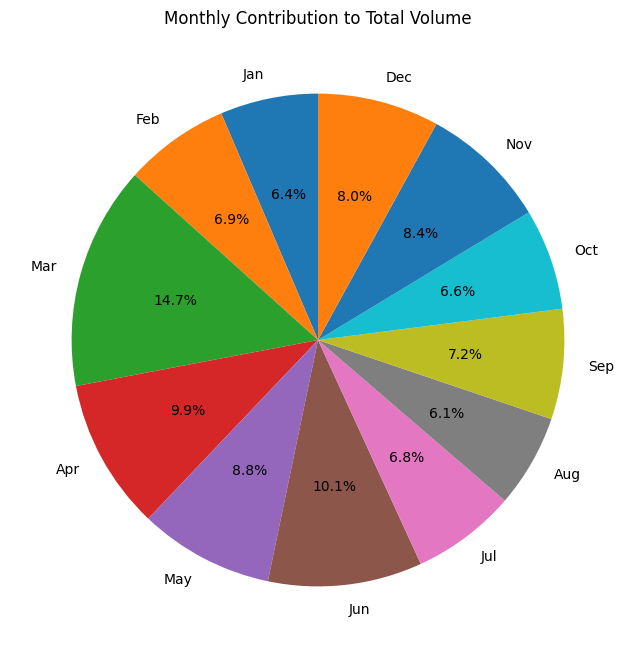

In [41]:
# Second Question: In a specific year(I chose 2020), what proportion of total trading volume comes from each month?
import pandas as pd
import matplotlib.pyplot as plt
import calendar
df = pd.read_csv("/content/Data4Change/Market.csv")
df = df.dropna()
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
year = 2020
year_data = df[df["Year"] == year]
monthly_volume = year_data.groupby("Month")["Volume"].sum().sort_index()
labels = [calendar.month_abbr[i] for i in monthly_volume.index]
plt.figure(figsize=(8,8))
plt.pie(monthly_volume, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Monthly Contribution to Total Volume")
plt.show()

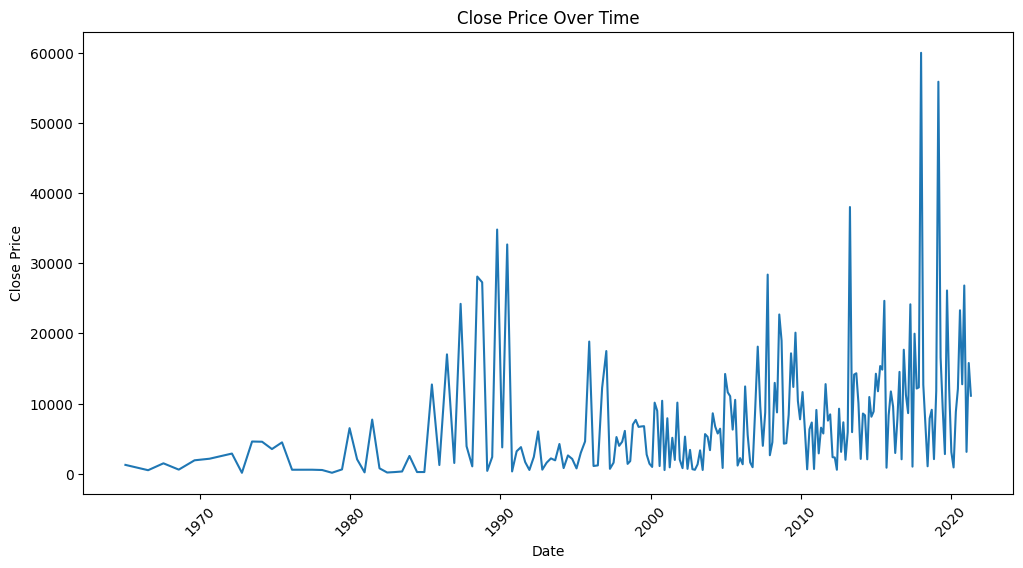

In [48]:
# Third Question: How does the Close price change over time?
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/Data4Change/Market.csv")
df = df.dropna()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df_small = df.iloc[::500]
plt.figure(figsize=(12,6))
plt.plot(df_small["Date"], df_small["Close"])
plt.title("Average Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()